# Per-Persona Value Drift Analysis

Visualises how annotated alignment scores change across journal time steps for each persona, across all 10 Schwartz value dimensions.

In [13]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=0.9)

# --- Load annotations ---
files = {
    "JL": "../../logs/annotations/jl.parquet",
    "KM": "../../logs/annotations/km.parquet",
    "Des": "../../logs/annotations/des.parquet",
}

value_cols = [
    "alignment_self_direction", "alignment_stimulation", "alignment_hedonism",
    "alignment_achievement", "alignment_power", "alignment_security",
    "alignment_conformity", "alignment_tradition", "alignment_benevolence",
    "alignment_universalism",
]
short_names = [c.replace("alignment_", "").replace("_", "-") for c in value_cols]

dfs = [pl.read_parquet(p) for p in files.values()]
raw = pl.concat(dfs)

# --- Load persona registry for names ---
registry = pl.read_parquet("../../logs/registry/personas.parquet").select(
    ["persona_id", "name", "core_values"]
)
id_to_name = dict(zip(
    registry["persona_id"].to_list(),
    registry["name"].to_list(),
))
id_to_core = dict(zip(
    registry["persona_id"].to_list(),
    registry["core_values"].to_list(),
))

# Mean across annotators per (persona, t_index)
mean_df = (
    raw.group_by(["persona_id", "t_index"])
    .agg([pl.col(c).cast(pl.Float64).mean().alias(c) for c in value_cols])
    .sort(["persona_id", "t_index"])
)

persona_ids = sorted(mean_df.select("persona_id").unique().to_series().to_list())
persona_labels = [id_to_name.get(pid, pid[:8]) for pid in persona_ids]

print(f"Loaded {len(raw)} annotations across {len(persona_ids)} personas\n")
for pid, label in zip(persona_ids, persona_labels):
    cv = id_to_core.get(pid, [])
    n = mean_df.filter(pl.col("persona_id") == pid).shape[0]
    print(f"  {label:25s}  core={', '.join(cv):35s}  {n} steps")

Loaded 380 annotations across 24 personas

  Emma Lindqvist             core=Security                             3 steps
  Tariq Al-Rashid            core=Conformity, Hedonism                 4 steps
  Patricia Moreno            core=Universalism                         6 steps
  Fatima Al-Hassan           core=Benevolence                          3 steps
  Marcus Chen                core=Self-Direction                       8 steps
  Karim Nazari               core=Hedonism, Self-Direction             9 steps
  Lukas Bergmann             core=Conformity, Self-Direction           3 steps
  Tariq Al-Rashid            core=Power                                3 steps
  Farid Al-Rashid            core=Tradition                            8 steps
  Tariq Al-Mansouri          core=Benevolence, Universalism            5 steps
  Layla Mansour              core=Stimulation, Security                3 steps
  Nabil Khoury               core=Security, Conformity                 9 steps
  Maya Ch

## Per-Persona Heatmaps

Each heatmap shows one persona's trajectory: rows = value dimensions, columns = journal time steps. Colour encodes mean annotator alignment: **blue = misaligned (-1)**, **white = neutral (0)**, **red = aligned (+1)**. Drift shows up as colour changes left-to-right.

In [ ]:
# --- Per-persona heatmaps (grid layout) ---
n_personas = len(persona_ids)
n_cols = 4
n_rows = int(np.ceil(n_personas / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows))
axes_flat = axes.flatten()
cmap = sns.diverging_palette(240, 10, as_cmap=True)  # blue-white-red

for idx, (pid, label) in enumerate(zip(persona_ids, persona_labels)):
    ax = axes_flat[idx]
    pdata = mean_df.filter(pl.col("persona_id") == pid).sort("t_index")
    t_indices = pdata["t_index"].to_list()
    matrix = np.array([pdata[c].to_list() for c in value_cols])  # (10, T)

    sns.heatmap(
        matrix, ax=ax, cmap=cmap, center=0, vmin=-1, vmax=1,
        xticklabels=t_indices, yticklabels=short_names if idx % n_cols == 0 else False,
        cbar=False, linewidths=0.5, linecolor="white",
    )
    cv = id_to_core.get(pid, [])
    ax.set_title(f"{label}\n({', '.join(cv)})", fontsize=9, fontweight="bold")
    ax.set_xlabel("t" if idx >= (n_rows - 1) * n_cols else "")
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

# Hide unused subplots
for idx in range(n_personas, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Shared colourbar
fig.subplots_adjust(right=0.92, hspace=0.55, wspace=0.15)
cbar_ax = fig.add_axes([0.94, 0.25, 0.015, 0.5])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(-1, 1))
cbar = fig.colorbar(sm, cax=cbar_ax, ticks=[-1, 0, 1])
cbar.ax.set_yticklabels(["misaligned", "neutral", "aligned"])

fig.suptitle("Per-Persona Value Alignment Over Time", fontsize=14, fontweight="bold", y=1.01)
plt.show()

## Per-Persona Alignment Trajectories

### How to read these plots

Each small panel is **one persona's journey** through their journal entries over time.

**Axes:**
- **X-axis (`t_index`)** — the journal entry number, in chronological order. `t=0` is the persona's first journal entry, `t=1` the second, and so on.
- **Y-axis (`alignment`)** — how well the persona's *behaviour* in that journal entry matches what they *declared* as important. The scale has three levels:
  - **+1 (aligned):** the journal entry clearly reflects this value in action (e.g., a persona who values achievement writes about pushing hard on a goal)
  - **0 (neutral):** no meaningful signal about this value — the entry neither supports nor contradicts it
  - **-1 (misaligned):** the journal entry shows behaviour that *contradicts* this declared value (e.g., a persona who values benevolence writes about ignoring a friend in need)

**Lines & colours:** each coloured line is one of the 10 Schwartz value dimensions (see legend on the right). Only dimensions with at least one non-zero annotation are shown per persona — if a line is missing, all annotators scored it as neutral across every time step.

**What drift looks like:** a line that moves from 0 → +1 or 0 → -1 over time shows the persona's behaviour shifting relative to their values. Lines that stay flat at 0 mean that dimension is stable (or just not surfaced in the journal text). A line that swings between +1 and -1 indicates oscillating tension — the persona acts on the value sometimes and against it other times.

**Fractional values (e.g., 0.33, 0.67):** these appear because the score is *averaged across 3 annotators*. A value of 0.33 means one annotator saw alignment (+1) while the other two saw neutral (0). A value of -0.33 means one annotator saw misalignment. These fractional scores indicate annotator disagreement and can be read as "weak" or "ambiguous" signals.

### What to look for
- **Flat lines at 0** — the value is dormant in this persona's journal entries
- **Sustained +1 or -1** — consistent alignment or misalignment (stable behaviour)
- **Transitions (e.g., +1 → 0 → -1)** — this is *drift*: behaviour changing relative to declared values over time. This is exactly what the VIF is designed to detect
- **Multiple lines diverging** — a persona experiencing tension across several value dimensions simultaneously

In [ ]:
# --- Per-persona line plots ---
palette = sns.color_palette("tab10", n_colors=10)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
axes_flat = axes.flatten()

for idx, (pid, label) in enumerate(zip(persona_ids, persona_labels)):
    ax = axes_flat[idx]
    pdata = mean_df.filter(pl.col("persona_id") == pid).sort("t_index")
    t = pdata["t_index"].to_list()

    active_dims = []
    for i, c in enumerate(value_cols):
        vals = pdata[c].to_list()
        if any(abs(v) > 0.01 for v in vals):
            active_dims.append((i, c, vals))

    for i, c, vals in active_dims:
        ax.plot(t, vals, marker="o", markersize=3, linewidth=1.5,
                color=palette[i], label=short_names[i], alpha=0.85)

    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_ylim(-1.15, 1.15)
    ax.yaxis.set_major_locator(ticker.FixedLocator([-1, 0, 1]))
    cv = id_to_core.get(pid, [])
    ax.set_title(f"{label}\n({', '.join(cv)})", fontsize=9, fontweight="bold")
    ax.tick_params(axis="both", labelsize=7)
    if idx % n_cols == 0:
        ax.set_ylabel("alignment")
    if idx >= (n_rows - 1) * n_cols:
        ax.set_xlabel("t_index")

for idx in range(n_personas, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Shared legend
handles = [plt.Line2D([0], [0], color=palette[i], lw=2, label=short_names[i])
           for i in range(10)]
fig.legend(handles=handles, loc="center right", bbox_to_anchor=(1.08, 0.5),
           fontsize=8, title="Value", title_fontsize=9)
fig.subplots_adjust(right=0.9, hspace=0.55, wspace=0.2)
fig.suptitle("Per-Persona Alignment Trajectories", fontsize=14, fontweight="bold", y=1.01)
plt.show()

## Drift Summary

Total absolute drift per persona across all dimensions, sorted by magnitude. Personas with longer trajectories and higher drift are the strongest candidates for VIF tension detection.

In [ ]:
# --- Drift summary bar chart ---
drifts = []
for pid in persona_ids:
    pdata = mean_df.filter(pl.col("persona_id") == pid).sort("t_index")
    if pdata.shape[0] < 2:
        continue
    first = pdata.head(1)
    last = pdata.tail(1)
    total = sum(abs(last[c].item() - first[c].item()) for c in value_cols)
    label = id_to_name.get(pid, pid[:8])
    drifts.append({"persona": label, "n_steps": pdata.shape[0], "total_abs_drift": total})

drift_df = pl.DataFrame(drifts).sort("total_abs_drift", descending=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("YlOrRd", n_colors=len(drift_df))
bars = ax.barh(
    drift_df["persona"].to_list()[::-1],
    drift_df["total_abs_drift"].to_list()[::-1],
    color=colors[::-1],
)

# Annotate with n_steps
for i, (steps, drift_val) in enumerate(zip(
    drift_df["n_steps"].to_list()[::-1],
    drift_df["total_abs_drift"].to_list()[::-1],
)):
    ax.text(drift_val + 0.1, i, f"{steps}t", va="center", fontsize=8, color="grey")

ax.set_xlabel("Total Absolute Drift (sum across 10 dimensions)")
ax.set_title("Per-Persona Drift Magnitude (label = number of time steps)", fontweight="bold")
ax.axvline(x=3, color="red", linestyle="--", alpha=0.4, label="high-drift threshold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Per-Persona Interpretations

Narrative reading of each persona's drift trajectory, grounded in their declared core values. Organised from highest to lowest total drift.

### Lukas Bergmann — Core: Conformity, Self-Direction | 3 steps | Drift: 7.0

The highest-drift persona in the dataset. Lukas declares both conformity *and* self-direction — values that inherently tension each other (one demands fitting in, the other demands autonomy). His trajectory shows this playing out dramatically:

- **Achievement** swings from -1 → 0 → +1 (full reversal in 3 steps) — he starts actively misaligned, then pivots hard toward achievement-oriented behaviour.
- **Conformity** drops from +1 → -1 → 0 — starts strongly conforming, then rebels, then settles to neutral. This is a direct drift *away* from a declared core value.
- **Self-direction** rises from 0 → +1 → +1 — behaviour increasingly aligns with this declared value.
- **Benevolence** and **hedonism** both end at -1 — active misalignment emerging by the final entry.

**VIF interpretation:** Classic "breaking out" narrative. Lukas starts by following rules (conformity) but progressively shifts toward autonomy (self-direction) and ambition (achievement), at the cost of caring for others (benevolence) and enjoyment (hedonism). The VIF should flag the conformity collapse as a core-value tension.

---

### Tariq Al-Rashid (056f46ad) — Core: Conformity, Hedonism | 4 steps | Drift: 5.0

Strong erosion of both declared core values:

- **Conformity** drops from +1 → -0.33 — starts fully aligned, ends misaligned. Clear drift away from a core value.
- **Hedonism** drops from +0.67 → 0 — fading alignment with the other core value.
- **Tradition** drops from +1 → 0 — parallel erosion of conservation values.
- **Achievement** rises from 0 → +1 — new behaviour pattern emerges that wasn't present initially.

**VIF interpretation:** Tariq's journal shows a persona abandoning conformity and tradition in favour of achievement. Both core values are drifting negative. This is exactly the kind of "values erosion under life pressure" pattern Twinkl is designed to surface.

---

### Nabil Khoury — Core: Security, Conformity | 9 steps | Drift: 5.0

A long trajectory with oscillating tensions:

- **Security** starts at +1 but oscillates, ending at 0 — intermittent drift away from core value.
- **Conformity** similarly starts at +1 and ends at 0 — same pattern of erosion.
- **Self-direction** repeatedly dips to -1 — this persona is actively *resisting* autonomy, consistent with security/conformity values, but the pattern is unstable.
- **Stimulation** swings between -1 and 0 — actively avoids novelty, again consistent, but volatile.
- **Achievement** and **tradition** both rise over time — new behavioural patterns emerging.

**VIF interpretation:** Nabil shows a "slow fade" pattern — core values (security, conformity) don't collapse but gradually lose signal strength. The oscillation in self-direction suggests internal conflict: sometimes conforming, sometimes pushing back. The VIF should track the *volatility* of these signals, not just the endpoint drift.

---

### Valentina Reyes — Core: Tradition, Universalism | 6 steps | Drift: 5.0

Both core values show strong drift:

- **Tradition** oscillates wildly: +0.33 → -1 → +0.67 → -1 → 0 → -1 — mostly misaligned by the end. A declared core value that her behaviour repeatedly contradicts.
- **Universalism** drops from +1 → 0 with oscillation — fading alignment with core value.
- **Conformity** drops from +1 → 0 in one step, then stays flat — sharp early abandonment.
- **Hedonism** drifts to -0.67 — increasingly resists pleasure/enjoyment.

**VIF interpretation:** Valentina's tradition score is the most volatile single dimension in the dataset — swinging between alignment and misalignment every other entry. This "oscillating tension" pattern is particularly interesting for VIF: it's not a clean drift but a struggle. The universalism fade is subtler but steady.

---

### Farid Al-Rashid — Core: Tradition | 8 steps | Drift: 4.0

Long trajectory with intermittent engagement:

- **Tradition** starts at +1 and oscillates, ending at 0 — aligned in some entries, absent in others, never misaligned. The core value isn't rejected but becomes less consistently expressed.
- **Self-direction** starts at +1 then drops to 0 — early autonomy fades.
- **Achievement** is spiky: +1 → 0 → +1 → 0 repeatedly — intermittent drive.
- **Benevolence** trends upward, ending at +1 — a new value pattern emerges.

**VIF interpretation:** Unlike Lukas's dramatic break, Farid shows a "quiet drift" — tradition doesn't collapse but becomes intermittent. The rising benevolence suggests a shift from rule-following to people-caring. The VIF should distinguish between *abandonment* and *dilution* of values.

---

### Park Jiyeon — Core: Tradition, Security | 5 steps | Drift: 3.67

Steady directional drift:

- **Self-direction** drops steadily from 0 → -1 — increasingly *avoids* autonomy. Consistent with valuing tradition/security but intensifying over time.
- **Stimulation** also drops from -0.33 → -1 — progressively rejects novelty.
- **Security** rises from +0.33 → +1 — *strengthening* alignment with core value.
- **Benevolence** drops from +0.67 → 0 — caring behaviour fades.

**VIF interpretation:** Park Jiyeon is the opposite of Lukas — she's *doubling down* on her conservative values (security strengthens, stimulation/self-direction are increasingly rejected). The drift here isn't away from values but toward a more rigid expression of them. The VIF should recognise this as alignment-intensification, not tension.

---

### Tariq Al-Rashid (114c62d8) — Core: Power | 3 steps | Drift: 3.33

Short but dramatic:

- **Power** drops from +1 → -0.67 → 0 — core value goes from fully aligned to absent in 3 steps.
- **Benevolence** rises from -0.67 → 0 → +0.67 — exact mirror of power's decline.
- **Self-direction** rises from 0 → +0.67 — new pattern emerging.

**VIF interpretation:** A persona pivoting from power-oriented to benevolence-oriented behaviour. The power/benevolence mirror is textbook Schwartz opposition (power and benevolence sit on opposite sides of the value circle). Clean signal for VIF tension detection.

---

### Harold Delacroix — Core: Conformity, Power | 12 steps | Drift: 3.0

The longest trajectory in the dataset:

- **Power** is extremely volatile: +1 → 0 → -1 → -0.33 → ... → 0 — swings across the full range repeatedly. Core value with chaotic expression.
- **Achievement** trends upward over 12 steps: 0 → +1 — gradual new alignment.
- **Conformity** stays moderately positive throughout (~0.33 average) — this core value is stable.
- **Self-direction** oscillates between -0.33 and +1 — erratic.

**VIF interpretation:** Harold demonstrates that long trajectories can show both stability (conformity holds) and chaos (power oscillates wildly). The VIF needs to handle these differently — conformity is a "quiet constant" while power is an "unresolved tension" despite both being declared core values.

---

### Patricia Moreno — Core: Universalism | 6 steps | Drift: 3.0

- **Universalism** oscillates: +1 → -1 → +1 → 0 → 0 → +1 — dramatic swings but returns to alignment. Core value is contested but ultimately held.
- **Self-direction** mirrors the universalism pattern almost exactly — these move together.
- **Achievement** and **power** both drop to -1 in the final entry — late-stage misalignment on self-enhancement values.
- **Tradition** starts at +1, then fades to 0 — gradual erosion.
- **Benevolence** stabilises at +1 in the latter half — strengthening prosocial behaviour.

**VIF interpretation:** Patricia's universalism swings are extreme but ultimately resilient. The late-stage rejection of achievement/power alongside rising benevolence suggests a persona increasingly committed to prosocial values, consistent with her declared universalism. The early oscillation may reflect uncertainty rather than true drift.

---

### Tariq Al-Mansouri — Core: Benevolence, Universalism | 5 steps | Drift: 3.0

- **Benevolence** starts at +1 and slowly fades to +0.33 — still positive but weakening. Core value gradually diluting.
- **Hedonism** drops steadily from 0 → -1 — increasingly active misalignment.
- **Tradition** drops from +0.67 → 0 — conservation values eroding.
- **Universalism** rises initially (+1 at t=1) but settles to +0.33 — unstable.

**VIF interpretation:** A subtle erosion pattern. Neither core value collapses, but both lose intensity. The hedonism misalignment growing to -1 is notable — this persona increasingly *resists* pleasure, which may be related to the benevolence/universalism orientation (self-sacrifice pattern).

---

### Marcus Chen (e809d252) — Core: Universalism, Tradition | 11 steps | Drift: 3.0

Second-longest trajectory:

- **Tradition** rises from 0 → +0.67 over 11 entries — gradual strengthening of a core value. Positive drift.
- **Benevolence** rises from 0 → +1 — strong prosocial trend emerging.
- **Universalism** oscillates around a slight downward trend: +1 → +0.33 — core value still present but less consistently expressed.
- **Self-direction** is spiky but no net drift.

**VIF interpretation:** Marcus shows core value *strengthening* on tradition while universalism slightly fades. The rising benevolence aligns with the prosocial orientation of both core values. This is a "values consolidation" trajectory — behaviour becoming more consistent with intent over time, which the VIF should recognise as positive alignment rather than tension.

---

### Remaining personas (drift < 3.0)

**Yasmin Khalil** (Hedonism, 9 steps, drift 2.0): Hedonism stays consistently aligned (+1 most entries). Security drifts to -1. Self-direction rises. Core value is stable; drift is on peripheral dimensions.

**Maya Chen** (Achievement, Stimulation, 6 steps, drift 2.0): Both core values remain well-aligned throughout. Achievement trends slightly upward. Conformity recovers from -0.67 to 0. Low-drift, stable persona.

**Karim Nazari** (Hedonism, Self-Direction, 9 steps, drift 2.33): Both core values oscillate but always return to alignment. Hedonism ends at +1, self-direction at +1. Conformity recovers. This persona shows *volatile but resilient* core values.

**Chen Wei-Lin** (Security, Power, 10 steps, drift 1.67): Power is highly volatile (-1 to +0.67 range) but with low net drift. Achievement rises. Security stays weakly positive. Long trajectory with modest drift.

**Marcus Chen (0d272008)** (Self-Direction, 8 steps, drift 1.33): Self-direction is rock-solid at +1 across nearly all entries. Small movements on achievement and benevolence. The most stable core-value alignment in the dataset.

**Fatima Al-Hassan** (Benevolence, 3 steps, drift 1.0): Benevolence is perfect +1 across all entries. Hedonism is consistently misaligned (-0.67 to -1). Short but clear: core value fully aligned, pleasure actively rejected.

**Erik Lindqvist** (Self-Direction, Conformity, 4 steps, drift 1.67): Conformity starts at +1 and fades slightly. Self-direction stays negative to neutral — declared core value that behaviour doesn't match. Benevolence rises. Mild tension between declared self-direction and conformist behaviour.

**Layla Mansour** (Stimulation, Security, 3 steps, drift 1.33): Stimulation stays aligned at +1. Security recovers from -0.67 to 0. Short trajectory, modest drift, core values holding.

**Nadia Tehrani** (Universalism, Self-Direction, 4 steps, drift 1.33): Self-direction strengthens to +1. Universalism fades from +1 → 0. Achievement rises. Shifting from prosocial to self-enhancement values.

**Tariq Haddad** (Benevolence, Achievement, 9 steps, drift 0.67): Both core values remain well-aligned throughout (achievement ~+0.67–1.0, benevolence ~+0.33–1.0). The lowest-drift persona with a long trajectory — remarkably stable.

**Priya Sharma** (Hedonism, Achievement, 8 steps, drift 0.33): Achievement stays mostly aligned. Hedonism oscillates wildly between -1 and +1 but nets to zero drift. Benevolence is the most volatile dimension. Nearly zero net drift despite 8 steps.

**Kevin Lim** (Hedonism, 2 steps, drift 1.0): Only 2 data points — too short for meaningful trajectory analysis. Hedonism stays at +1. Tradition drops. Insufficient data for drift conclusions.

## Inter-Annotator Disagreement on Drift

Shows where annotators disagree most — high disagreement on a dimension suggests ambiguous alignment signals in the journal text.

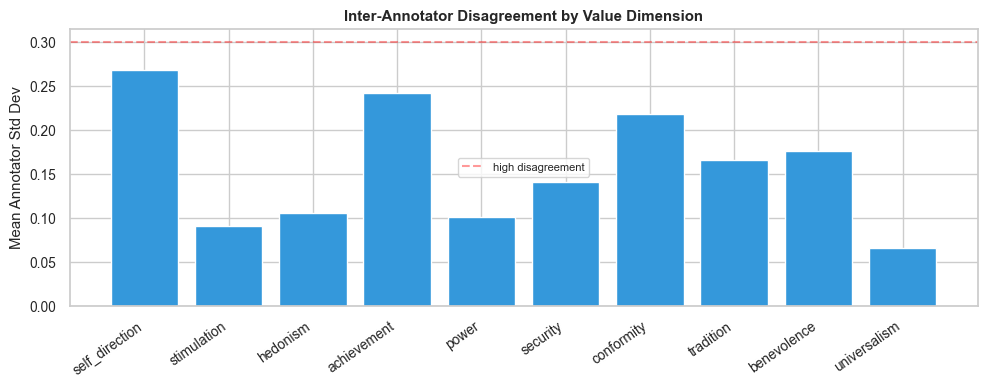

In [17]:
# --- Inter-annotator disagreement per dimension per persona ---
std_df = (
    raw.group_by(["persona_id", "t_index"])
    .agg([pl.col(c).cast(pl.Float64).std().alias(c) for c in value_cols])
    .sort(["persona_id", "t_index"])
)

# Average std across all (persona, t_index) pairs per dimension
avg_std = {}
for c in value_cols:
    vals = std_df[c].drop_nulls().to_list()
    avg_std[c.replace("alignment_", "")] = sum(vals) / len(vals) if vals else 0

fig, ax = plt.subplots(figsize=(10, 4))
dims = list(avg_std.keys())
vals = list(avg_std.values())
colors = ["#e74c3c" if v > 0.3 else "#3498db" for v in vals]
ax.bar(dims, vals, color=colors)
ax.set_ylabel("Mean Annotator Std Dev")
ax.set_title("Inter-Annotator Disagreement by Value Dimension", fontweight="bold")
ax.axhline(0.3, color="red", linestyle="--", alpha=0.4, label="high disagreement")
ax.legend(fontsize=8)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()